# TH-Challenge 6 — Análisis de Logs

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('server_logs.csv')
df['timestamp_event'] = pd.to_datetime(df['timestamp_event'])
df.head()

,timestamp_event,received_at,service_name,severity,message,trace_id,request_id,method,endpoint,status_code,latency_ms,host,env,region,log_type
0,2026-01-10 00:02:39.029160+00:00,2026-01-10T00:02:39.097160Z,orders-service,INFO,Request completed,bd8e6ebe717b4c43ba5e72e1668641a8,e6b3009adcad,GET,/orders/create,200,99,orders-service-pod-03,prod,sa-east-1,request
1,2026-01-10 00:02:46.081021+00:00,2026-01-10T00:02:46.196021Z,api-gateway,INFO,Background job completed,40ac5ff97bae43d5b8045484725e0aca,e2aa1cccd1cf,GET,/health,200,122,api-gateway-pod-01,prod,sa-east-1,request
2,2026-01-10 00:04:01.648849+00:00,2026-01-10T00:04:01.718849Z,notification-service,WARN,Rate limit nearing threshold,c048b378759a4c54a6f7d7251a6acc88,c74106ca8581,POST,/notify/sms,200,646,notification-service-pod-03,prod,sa-east-1,request
3,2026-01-10 00:05:08.148346+00:00,2026-01-10T00:05:08.236346Z,api-gateway,INFO,Background job completed,072169f708c84227986bfda9f9657bdc,bf10fa3609bd,GET,/checkout,200,127,api-gateway-pod-03,prod,sa-east-1,request
4,2026-01-10 00:05:19.590837+00:00,2026-01-10T00:05:19.632837Z,inventory-service,INFO,Health check OK,e76a214131d24a4ea1acf389362e34cb,f672d669eda7,GET,/inv/release,200,144,inventory-service-pod-02,prod,sa-east-1,request


## 6.1 Exploración inicial

In [3]:
# Cuántos logs hay en total
print('Total de logs:', len(df))

Total de logs: 5795


In [4]:
# Qué severidad aparece más
df['severity'].value_counts()

severity
INFO        3542
WARN        1358
ERROR        775
CRITICAL     120
Name: count, dtype: int64

In [5]:
# Qué servicio genera más logs y cuál menos
df['service_name'].value_counts()

service_name
api-gateway             1509
orders-service          1057
inventory-service        964
payment-service          842
auth-service             778
notification-service     645
Name: count, dtype: int64

In [6]:
# Mensaje más repetido
df['message'].value_counts().head(5)

message
Health check OK                                   1196
Background job completed                          1185
Request completed                                 1161
Order creation failed - inventory lock timeout     197
Rate limit nearing threshold                       193
Name: count, dtype: int64

In [7]:
# Mensaje malo más repetido
# Un bad event es: severity ERROR o CRITICAL, o status_code >= 500
bad = df[(df['severity'].isin(['ERROR', 'CRITICAL'])) | (df['status_code'] >= 500)]
bad['message'].value_counts().head(5)

message
Order creation failed - inventory lock timeout    197
Payment gateway unavailable                       103
Database deadlock detected                         99
Checkout failed - upstream payment timeout         88
Possible credential stuffing detected              69
Name: count, dtype: int64

## 6.2 Detección del momento crítico

In [8]:
# Agrupamos en bins de 5 minutos
df_bins = df.set_index('timestamp_event').groupby(pd.Grouper(freq='5min'))

total_events = df_bins['service_name'].count()

bad_mask = (df['severity'].isin(['ERROR', 'CRITICAL'])) | (df['status_code'] >= 500)
df['is_bad'] = bad_mask

bad_events = df.set_index('timestamp_event').groupby(pd.Grouper(freq='5min'))['is_bad'].sum()

ventanas = pd.DataFrame({
    'total_events': total_events,
    'bad_events': bad_events
})

ventanas['bad_rate'] = ventanas['bad_events'] / ventanas['total_events']

# Filtramos ventanas con al menos 20 eventos
ventanas_filtradas = ventanas[ventanas['total_events'] >= 20]

# Top 5 por bad_rate
ventanas_filtradas.sort_values('bad_rate', ascending=False).head(5)

,total_events,bad_events,bad_rate
timestamp_event,,,
2026-01-10 11:10:00+00:00,189,110,0.582011
2026-01-10 11:15:00+00:00,228,129,0.565789
2026-01-10 11:20:00+00:00,111,59,0.531532
2026-01-11 14:35:00+00:00,255,117,0.458824
2026-01-11 14:30:00+00:00,156,68,0.435897


In [9]:
# Momento crítico: ventana con mayor bad_rate
momento_critico = ventanas_filtradas['bad_rate'].idxmax()
print('Momento crítico:', momento_critico)

Momento crítico: 2026-01-10 11:10:00+00:00


## 6.3 Diagnóstico dentro del momento crítico

In [10]:
# Filtramos los logs dentro de esa ventana de 5 minutos
ventana_fin = momento_critico + pd.Timedelta(minutes=5)
en_incidente = df[(df['timestamp_event'] >= momento_critico) & (df['timestamp_event'] < ventana_fin)]
bad_en_incidente = en_incidente[(en_incidente['severity'].isin(['ERROR', 'CRITICAL'])) | (en_incidente['status_code'] >= 500)]

print('Total eventos en la ventana:', len(en_incidente))
print('Bad events en la ventana:', len(bad_en_incidente))

Total eventos en la ventana: 189
Bad events en la ventana: 110


In [11]:
# Bad events por servicio (criterio: cantidad de bad events)
bad_en_incidente['service_name'].value_counts()

service_name
orders-service       72
inventory-service    37
payment-service       1
Name: count, dtype: int64

In [12]:
# Top 5 mensajes en bad events
bad_en_incidente['message'].value_counts().head(5)

message
Order creation failed - inventory lock timeout    72
Database deadlock detected                        37
External dependency error                          1
Name: count, dtype: int64

In [13]:
# Top 5 endpoints más comprometidos
bad_en_incidente['endpoint'].value_counts().head(5)

endpoint
/orders/cancel    26
/orders/create    25
/orders/status    21
/inv/reserve      18
/inv/stock        13
Name: count, dtype: int64

## 6.4 Qué cambió — Incidente vs Baseline

In [14]:
# Baseline: todo lo que NO está en el momento crítico
baseline = df[(df['timestamp_event'] < momento_critico) | (df['timestamp_event'] >= ventana_fin)]
bad_baseline = baseline[(baseline['severity'].isin(['ERROR', 'CRITICAL'])) | (baseline['status_code'] >= 500)]

comparacion = pd.DataFrame({
    'total_events':    [len(en_incidente),                                       len(baseline)],
    'bad_rate':        [len(bad_en_incidente) / len(en_incidente),               len(bad_baseline) / len(baseline)],
    'avg_latency_ms':  [en_incidente['latency_ms'].mean(),                       baseline['latency_ms'].mean()],
    '%_5xx':          [en_incidente[en_incidente['status_code'] >= 500].shape[0] / len(en_incidente),
                       baseline[baseline['status_code'] >= 500].shape[0] / len(baseline)]
}, index=['incidente', 'baseline'])

comparacion

,total_events,bad_rate,avg_latency_ms,%_5xx
incidente,189,0.582011,1589.687831,0.582011
baseline,5606,0.140029,521.094363,0.140029


## Gráficos

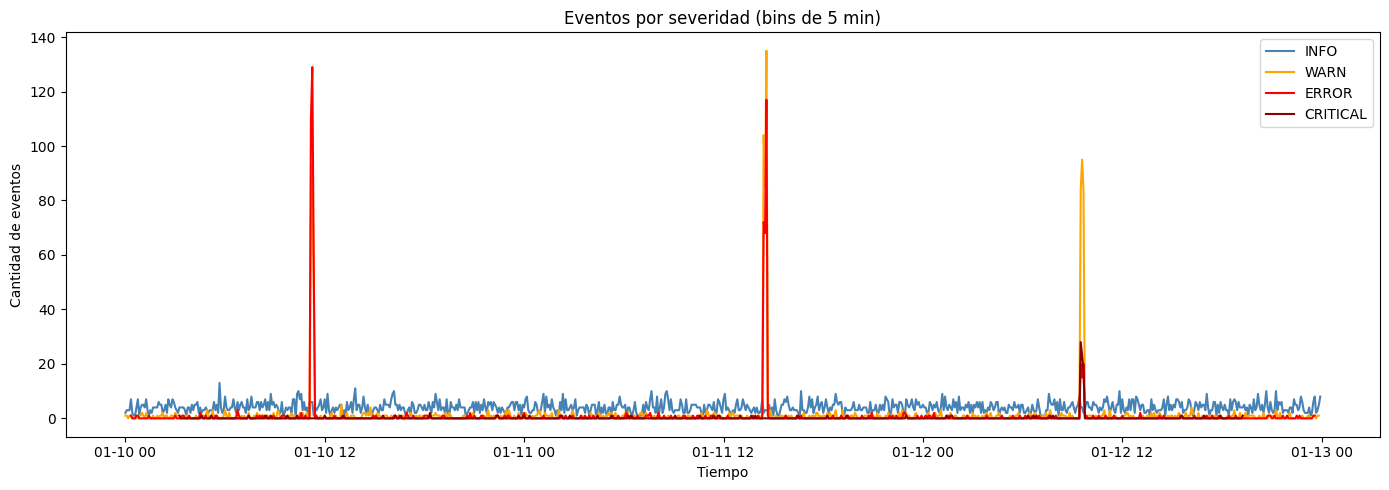

In [15]:
# Gráfico 1 — Eventos por severidad en bins de 5 min
colores = {'INFO': 'steelblue', 'WARN': 'orange', 'ERROR': 'red', 'CRITICAL': 'darkred'}

plt.figure(figsize=(14, 5))

for sev in ['INFO', 'WARN', 'ERROR', 'CRITICAL']:
    subset = df[df['severity'] == sev].set_index('timestamp_event')
    conteo = subset.groupby(pd.Grouper(freq='5min'))['service_name'].count()
    plt.plot(conteo.index, conteo.values, label=sev, color=colores[sev])

plt.title('Eventos por severidad (bins de 5 min)')
plt.xlabel('Tiempo')
plt.ylabel('Cantidad de eventos')
plt.legend()
plt.tight_layout()
plt.show()

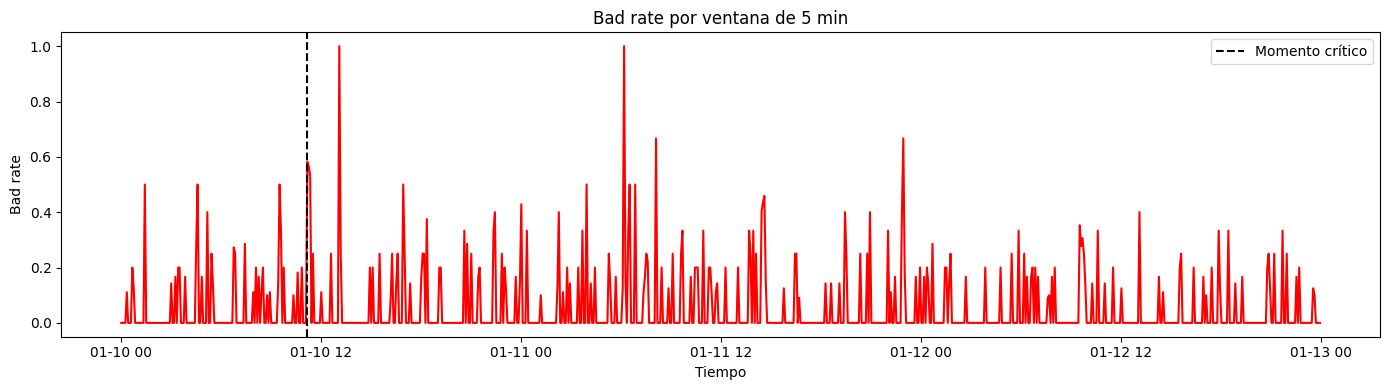

In [16]:
# Gráfico 2 — Bad rate en bins de 5 min
ventanas_todas = ventanas.copy()
ventanas_todas['bad_rate'] = ventanas_todas['bad_rate'].fillna(0)

plt.figure(figsize=(14, 4))
plt.plot(ventanas_todas.index, ventanas_todas['bad_rate'], color='red')
plt.axvline(x=momento_critico, color='black', linestyle='--', label='Momento crítico')
plt.title('Bad rate por ventana de 5 min')
plt.xlabel('Tiempo')
plt.ylabel('Bad rate')
plt.legend()
plt.tight_layout()
plt.show()

## Bonus — Trace ID dentro del momento crítico

In [17]:
# Elegimos un trace_id que tenga bad events en el momento crítico
trace_elegido = bad_en_incidente['trace_id'].value_counts().idxmax()
print('Trace elegido:', trace_elegido)

# Secuencia completa de ese trace ordenada por tiempo
traza = df[df['trace_id'] == trace_elegido].sort_values('timestamp_event')
traza[['timestamp_event', 'service_name', 'endpoint', 'status_code', 'severity', 'message', 'latency_ms']]

Trace elegido: e06c4ed1570f46efa88fde74338d9edd


,timestamp_event,service_name,endpoint,status_code,severity,message,latency_ms
690,2026-01-10 11:10:03.851393+00:00,orders-service,/orders/create,504,ERROR,Order creation failed - inventory lock timeout,1816
691,2026-01-10 11:10:03.856393+00:00,api-gateway,/checkout,200,WARN,Inventory endpoint degraded - high latency,625
692,2026-01-10 11:10:04.134393+00:00,inventory-service,/inv/reserve,504,ERROR,Database deadlock detected,860


In [18]:
# Primer bad event en ese trace
bad_en_traza = traza[(traza['severity'].isin(['ERROR', 'CRITICAL'])) | (traza['status_code'] >= 500)]
print('Primer bad event del trace:')
bad_en_traza.iloc[0][['timestamp_event', 'service_name', 'endpoint', 'status_code', 'severity', 'message']]

Primer bad event del trace:


timestamp_event                  2026-01-10 11:10:03.851393+00:00
service_name                                       orders-service
endpoint                                           /orders/create
status_code                                                   504
severity                                                    ERROR
message            Order creation failed - inventory lock timeout
Name: 690, dtype: object

## Conclusiones

El momento crítico ocurrió el **2026-01-10 a las 11:10 UTC**, una ventana de 5 minutos con 189 eventos y un bad rate de 58.2%.

El servicio más afectado fue **orders-service**, con 72 bad events dentro de esa ventana, seguido de inventory-service con 37.

Los endpoints más comprometidos fueron **/orders/cancel**, **/orders/create** y **/orders/status**, todos pertenecientes a orders-service.

El mensaje dominante fue **'Order creation failed - inventory lock timeout'** (72 ocurrencias), lo que sugiere que inventory-service dejó de responder y orders-service empezó a fallar en cascada.

Comparando contra el baseline: el bad rate pasó de **14% a 58.2%**, y la latencia promedio subió de **521ms a 1589ms** (3x más lenta). El %_5xx tuvo el mismo salto, lo que confirma que los errores fueron del lado del servidor, no del cliente.